Necessary imports...

In [40]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import OneHotEncoder

Read in the LastFM dataset. It contains userID-artistID pairs, along with the number of listening times (`"weight"` column) belonging to the pair.

In [41]:
data = pd.read_csv("hetrec2011-lastfm-2k/user_artists.dat", sep="\t")
data

,userID,artistID,weight
0,2,51,13883
1,2,52,11690
2,2,53,11351
3,2,54,10300
4,2,55,8983
...,...,...,...
92829,2100,18726,337
92830,2100,18727,297
92831,2100,18728,281
92832,2100,18729,280


Take a look at the log-distribution of these listening counts.

Text(0.5, 1.0, 'Distribution of Log Listen Counts\nfor Every User-Artist Pair')

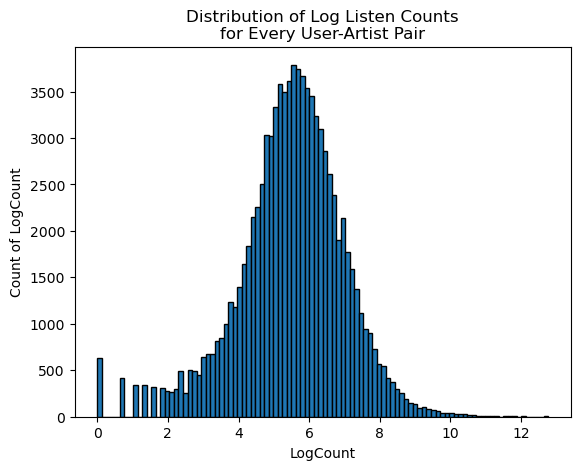

In [42]:
fig, ax = plt.subplots()
ax.hist(np.log(data["weight"]), bins=100, edgecolor="black")
ax.set_xlabel("LogCount")
ax.set_ylabel("Count of LogCount")
ax.set_title("Distribution of Log Listen Counts\nfor Every User-Artist Pair")

Create a pivot table that counts the total number of tracks a user has listened.

In [43]:
user_total_listens = pd.pivot_table(data, index=["userID"], values=["weight"], aggfunc="sum")
user_total_listens = user_total_listens.rename(columns={"weight": "user_total_listens"})
user_total_listens

,user_total_listens
userID,
2,168737
3,20501
4,26930
5,13159
6,1011
...,...
2095,4885
2096,62714
2097,13830


Visualize the distribution of the pivot table data.

Text(0.5, 1.0, 'Distribution of Log Listen Counts\nfor Every User')

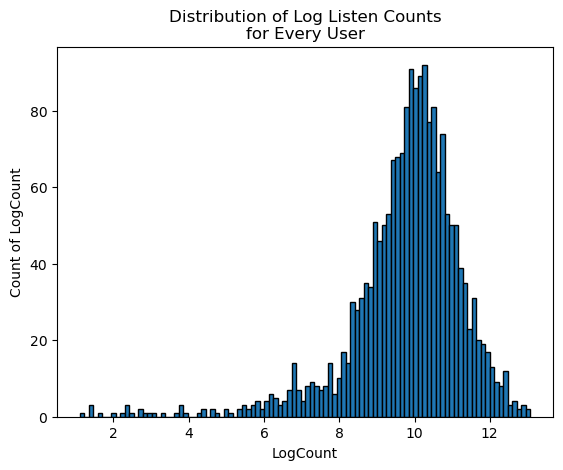

In [44]:
fig, ax = plt.subplots()
ax.hist(np.log(user_total_listens["user_total_listens"]), bins=100, edgecolor="black")
ax.set_xlabel("LogCount")
ax.set_ylabel("Count of LogCount")
ax.set_title("Distribution of Log Listen Counts\nfor Every User")

Create a pivot table that counts the total number of times that an artist has been listened to.

In [45]:
artist_total_listens = pd.pivot_table(data, index=["artistID"], values=["weight"], aggfunc="sum")
artist_total_listens = artist_total_listens.rename(columns={"weight": "artist_total_listens"})
artist_total_listens

,artist_total_listens
artistID,
1,771
2,8012
3,775
4,563
5,913
...,...
18741,301
18742,294
18743,287


Visualize the distribution of the pivot table data.

Text(0.5, 1.0, 'Distribution of Log Listen Counts\nfor Every Artist')

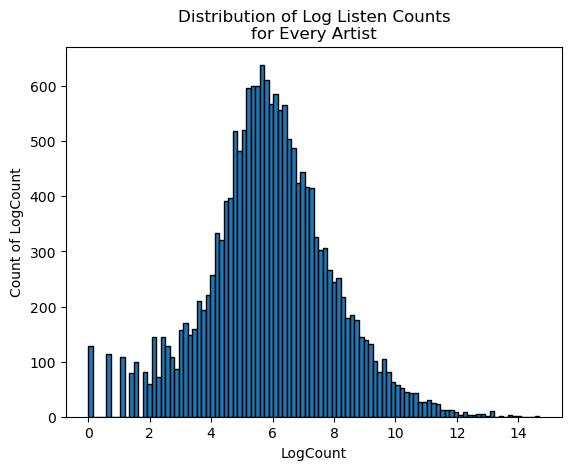

In [46]:
fig, ax = plt.subplots()
ax.hist(np.log(artist_total_listens["artist_total_listens"]), bins=100, edgecolor="black")
ax.set_xlabel("LogCount")
ax.set_ylabel("Count of LogCount")
ax.set_title("Distribution of Log Listen Counts\nfor Every Artist")

Merge the pivot table data with the source dataset.

In [47]:
data = data.join(user_total_listens, on="userID", how="left")
data = data.join(artist_total_listens, on="artistID", how="left")
data

,userID,artistID,weight,user_total_listens,artist_total_listens
0,2,51,13883,168737,348919
1,2,52,11690,168737,18787
2,2,53,11351,168737,44230
3,2,54,10300,168737,15927
4,2,55,8983,168737,449292
...,...,...,...,...,...
92829,2100,18726,337,30877,337
92830,2100,18727,297,30877,297
92831,2100,18728,281,30877,281
92832,2100,18729,280,30877,280


Load the user-artist tag data. This contains instances, when a user tagged a certain artist with a certain tag.

In [48]:
artist_tags = pd.read_csv("hetrec2011-lastfm-2k/user_taggedartists.dat", sep="\t")
artist_tags.drop(columns=["day", "month", "year"], inplace=True)
artist_tags

,userID,artistID,tagID
0,2,52,13
1,2,52,15
2,2,52,18
3,2,52,21
4,2,52,41
...,...,...,...
186474,2100,16437,4
186475,2100,16437,292
186476,2100,16437,2087
186477,2100,16437,2801


Take a look at the usage rate of every tag. Notice that most of the tags are only used a few times. We can drop these seldom used tags later, and unify them into a new, `"seldom_used"` tag.

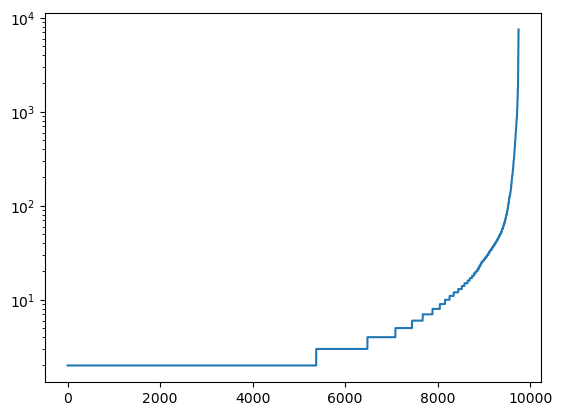

In [49]:
tag_id_counts = artist_tags["tagID"].value_counts()
fig, ax = plt.subplots()
ax.plot(sorted(1 + tag_id_counts.values))
ax.set_yscale("log")

Count the number of tags that have been used more than 50 times.

In [50]:
tag_id_count_cutoff = 50
np.sum(tag_id_counts > tag_id_count_cutoff)

np.int64(381)

Load in the tag ID resolver table. Merge it with the `tag_id_counts` table and filter it only for frequent tags.

In [51]:
tag_id_names = pd.read_csv("hetrec2011-lastfm-2k/tags_utf8.dat", sep="\t")
tag_id_names = tag_id_names.join(tag_id_counts, on="tagID", how="left")
tag_id_names["count"] = tag_id_names["count"].fillna(0.)
tag_id_names = tag_id_names[tag_id_names["count"] > tag_id_count_cutoff]
tag_id_names.rename(columns={"count": "tagID_count"}, inplace=True)
tag_id_names.set_index("tagID", inplace=True)
tag_id_names

,tagValue,tagID_count
tagID,,
1,metal,1729.0
2,alternative metal,212.0
4,black metal,301.0
5,death metal,582.0
6,industrial metal,210.0
...,...,...
10585,jukebox project,55.0
12029,tinosoft,52.0
12208,new wave and eighties,55.0


Merge the `"artist_tags"` table with the `tag_id_names` table. Also, we don't need the tag ID anymore and we don't care about who added the tag to that certain artist. After this, we can also fill in the `NaN` values with the aforementioned `"seldom_used"` tag.

In [52]:
artist_tags = artist_tags.join(tag_id_names["tagValue"], on="tagID", how="left")
artist_tags.drop(columns=["userID", "tagID"], inplace=True)
artist_tags["tagValue"] = artist_tags["tagValue"].fillna("seldom_used")
artist_tags

,artistID,tagValue
0,52,chillout
1,52,downtempo
2,52,electronic
3,52,trip-hop
4,52,seldom_used
...,...,...
186474,16437,black metal
186475,16437,folk
186476,16437,seldom_used
186477,16437,seldom_used


Encode the tag values using one-hot encoding. This will result in 382 dimensional one-hot encoded vectors.

In [53]:
tag_value_encoder = OneHotEncoder(sparse_output=False)
tag_value_encoder.fit(artist_tags["tagValue"].values[:, None])
tag_value_one_hot = tag_value_encoder.transform(artist_tags["tagValue"].values[:, None])
tag_value_one_hot = pd.DataFrame(data=tag_value_one_hot, columns=tag_value_encoder.categories_[0])
tag_value_one_hot

,00s,10s,1991,1992,2008,2009,2010,4m4zinq,50s,60s,...,underground hip-hop,underrated,urban,usa,visual kei,vocal,vocal trance,world,world music,worship
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
186474,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
186475,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
186476,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
186477,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Concatenate it with the `artist_tags` table and collapse it along the different artists. To every artist a tag probability mass function will be assigned this way (i.e. for every artist, we calculate the probability that he/she recieves a certain tag).

In [54]:
artist_tags = pd.concat([artist_tags, tag_value_one_hot], axis=1)
artist_tags.drop(columns=["tagValue"], inplace=True)  # this is redundant
artist_tags = pd.pivot_table(artist_tags, index="artistID", aggfunc="mean")
artist_tags

,00s,10s,1991,1992,2008,2009,2010,4m4zinq,50s,60s,...,underground hip-hop,underrated,urban,usa,visual kei,vocal,vocal trance,world,world music,worship
artistID,,,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.200000,0.000000,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.037037,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.136364,0.000000,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18737,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0
18739,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0
18740,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0


Select a random user to whom we want to recommend new artists. Collect its listening preference into a tag vector. Every artist will contribute with its own tag vector as many times as the user listened to him/her. After that, we normalize the vector.

In [83]:
random_user_id = np.random.choice(np.unique(data["userID"]))
random_user_data = data[data["userID"] == random_user_id]
random_user_preference_vec = np.zeros(artist_tags.shape[1])
for row_idx in range(random_user_data.shape[0]):
    row = random_user_data.iloc[row_idx]

    try:
        # If the user listened to an artist that didn't recieve any tags, 
        # then this indexing will fail. We simply skip it.
        artist_tag_vec = artist_tags.loc[row["artistID"]]
    except:
        continue
    
    random_user_preference_vec += artist_tag_vec.values * row["weight"]
random_user_preference_vec /= np.sum(random_user_preference_vec)  # normalize

Calculate the L1 distance of the user preference vector from every artist vector.

In [87]:
random_user_vs_artist_dist = np.sum(np.abs(artist_tags.values - random_user_preference_vec[None, :]), axis=1)
random_user_vs_artist_dist = pd.DataFrame(random_user_vs_artist_dist, index=artist_tags.index, columns=["distance"])
random_user_vs_artist_dist

,distance
artistID,
1,1.652487
2,1.872853
3,1.652487
4,1.721500
5,1.710971
...,...
18737,1.512836
18739,1.580863
18740,1.999274


Remove the artist the user has already listened to. Then, sort the remaining artists based on the distance and select the top 10 most similar artist IDs.

In [90]:
random_user_vs_artist_dist = random_user_vs_artist_dist[~random_user_vs_artist_dist.index.isin(random_user_data["artistID"])]
random_user_vs_artist_dist = random_user_vs_artist_dist.sort_values(by="distance")
random_user_vs_artist_dist.iloc[:10]

,distance
artistID,
65,0.726318
173,0.794742
217,0.796551
599,0.822007
533,0.833367
1510,0.837431
715,0.848196
215,0.854714
221,0.856214
